In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler, MinMaxScaler,LabelEncoder
import statsmodels.api as sm
import statsmodels.formula.api as smf
from itertools import combinations
from scipy.stats import chi2_contingency, boxcox, gaussian_kde, ttest_ind
from sklearn.preprocessing import LabelEncoder
from itertools import combinations
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import pickle

In [3]:
# fetch dataset
credit_approval = fetch_ucirepo(id=27)

# data (as pandas dataframes)
X = credit_approval.data.features
y = credit_approval.data.targets

# metadata
print(credit_approval.metadata)

# variable information
print(credit_approval.variables)

{'uci_id': 27, 'name': 'Credit Approval', 'repository_url': 'https://archive.ics.uci.edu/dataset/27/credit+approval', 'data_url': 'https://archive.ics.uci.edu/static/public/27/data.csv', 'abstract': 'This data concerns credit card applications; good mix of attributes', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 690, 'num_features': 15, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['A16'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1987, 'last_updated': 'Wed Aug 23 2023', 'dataset_doi': '10.24432/C5FS30', 'creators': ['J. R. Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This file concerns credit card applications.  All attribute names and values have been changed to meaningless symbols to protect confidentiality of the data.\r\n  \r\nThis dataset is interesting because there is a good mix of attributes --

In [4]:
df = credit_approval.data.original
df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,b,21.08,10.085,y,p,e,h,1.25,f,f,0,f,g,260.0,0,-
686,a,22.67,0.750,u,g,c,v,2.00,f,t,2,t,g,200.0,394,-
687,a,25.25,13.500,y,p,ff,ff,2.00,f,t,1,t,g,200.0,1,-
688,b,17.92,0.205,u,g,aa,v,0.04,f,f,0,f,g,280.0,750,-


In [5]:
df.describe()

,A2,A3,A8,A11,A14,A15
count,678.000000,690.000000,690.000000,690.00000,677.000000,690.000000
mean,31.568171,4.758725,2.223406,2.40000,184.014771,1017.385507
std,11.957862,4.978163,3.346513,4.86294,173.806768,5210.102598
min,13.750000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,22.602500,1.000000,0.165000,0.00000,75.000000,0.000000
50%,28.460000,2.750000,1.000000,0.00000,160.000000,5.000000
75%,38.230000,7.207500,2.625000,3.00000,276.000000,395.500000
max,80.250000,28.000000,28.500000,67.00000,2000.000000,100000.000000


In [6]:
df.shape

(690, 16)

In [7]:
df.columns.values

array(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11',
       'A12', 'A13', 'A14', 'A15', 'A16'], dtype=object)

In [8]:
df.dtypes

A1      object
A2     float64
A3     float64
A4      object
A5      object
A6      object
A7      object
A8     float64
A9      object
A10     object
A11      int64
A12     object
A13     object
A14    float64
A15      int64
A16     object
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    object 
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      684 non-null    object 
 4   A5      684 non-null    object 
 5   A6      681 non-null    object 
 6   A7      681 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    int64  
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  A16     690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB


In [10]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


In [11]:
df.tail()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
685,b,21.08,10.085,y,p,e,h,1.25,f,f,0,f,g,260.0,0,-
686,a,22.67,0.750,u,g,c,v,2.00,f,t,2,t,g,200.0,394,-
687,a,25.25,13.500,y,p,ff,ff,2.00,f,t,1,t,g,200.0,1,-
688,b,17.92,0.205,u,g,aa,v,0.04,f,f,0,f,g,280.0,750,-
689,b,35.00,3.375,u,g,c,h,8.29,f,f,0,t,g,0.0,0,-


In [12]:
df['A16'].value_counts()

A16
-    383
+    307
Name: count, dtype: int64

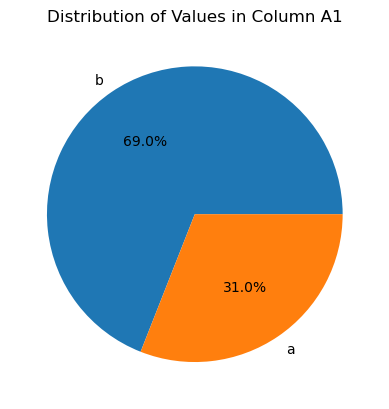

In [13]:
df['A1'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Values in Column A1')
plt.ylabel('')
plt.show()

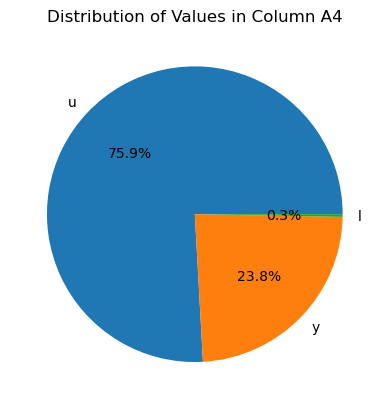

In [14]:
value_counts = df['A4'].value_counts()
plt.pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Values in Column A4')
plt.show()

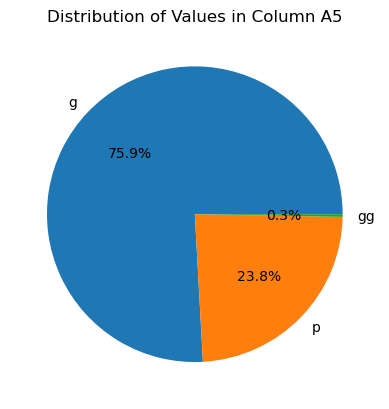

In [15]:
value_counts = df['A5'].value_counts()
plt.pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Values in Column A5')
plt.show()

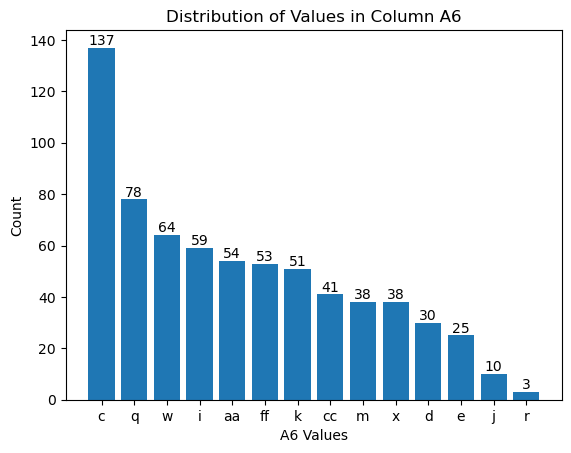

In [16]:
value_counts = df['A6'].value_counts()
plt.bar(value_counts.index, value_counts.values)
plt.xlabel('A6 Values')
plt.ylabel('Count')
plt.title('Distribution of Values in Column A6')
for i, v in enumerate(value_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.show()

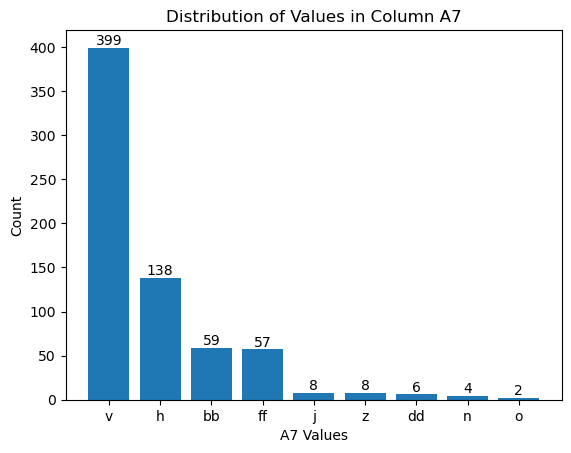

In [17]:
value_counts = df['A7'].value_counts()
plt.bar(value_counts.index, value_counts.values)
plt.xlabel('A7 Values')
plt.ylabel('Count')
plt.title('Distribution of Values in Column A7')
for i, v in enumerate(value_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.show()

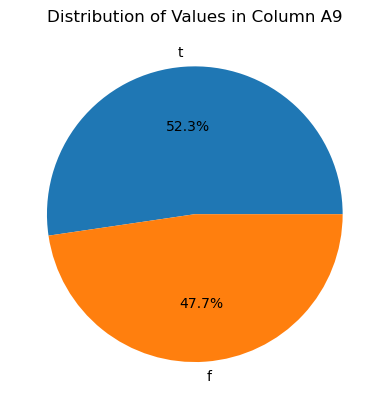

In [18]:
value_counts = df['A9'].value_counts()
plt.pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Values in Column A9')
plt.show()

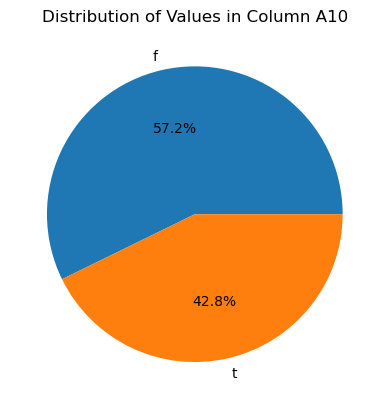

In [19]:
value_counts = df['A10'].value_counts()
plt.pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Values in Column A10')
plt.show()

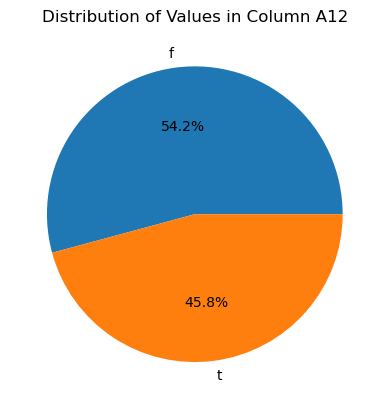

In [20]:
value_counts = df['A12'].value_counts()
plt.pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Values in Column A12')
plt.show()

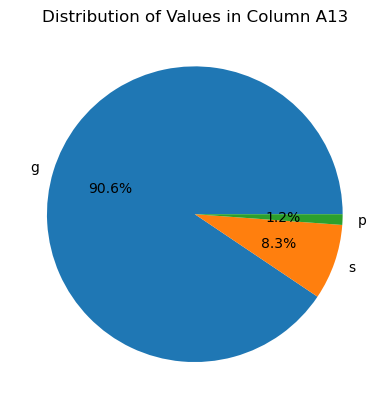

In [21]:
value_counts = df['A13'].value_counts()
plt.pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Values in Column A13')
plt.show()

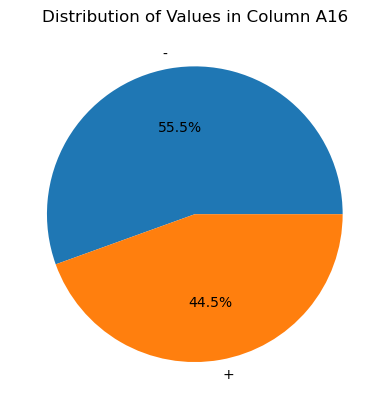

In [22]:
value_counts = df['A16'].value_counts()
plt.pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Values in Column A16')
plt.show()

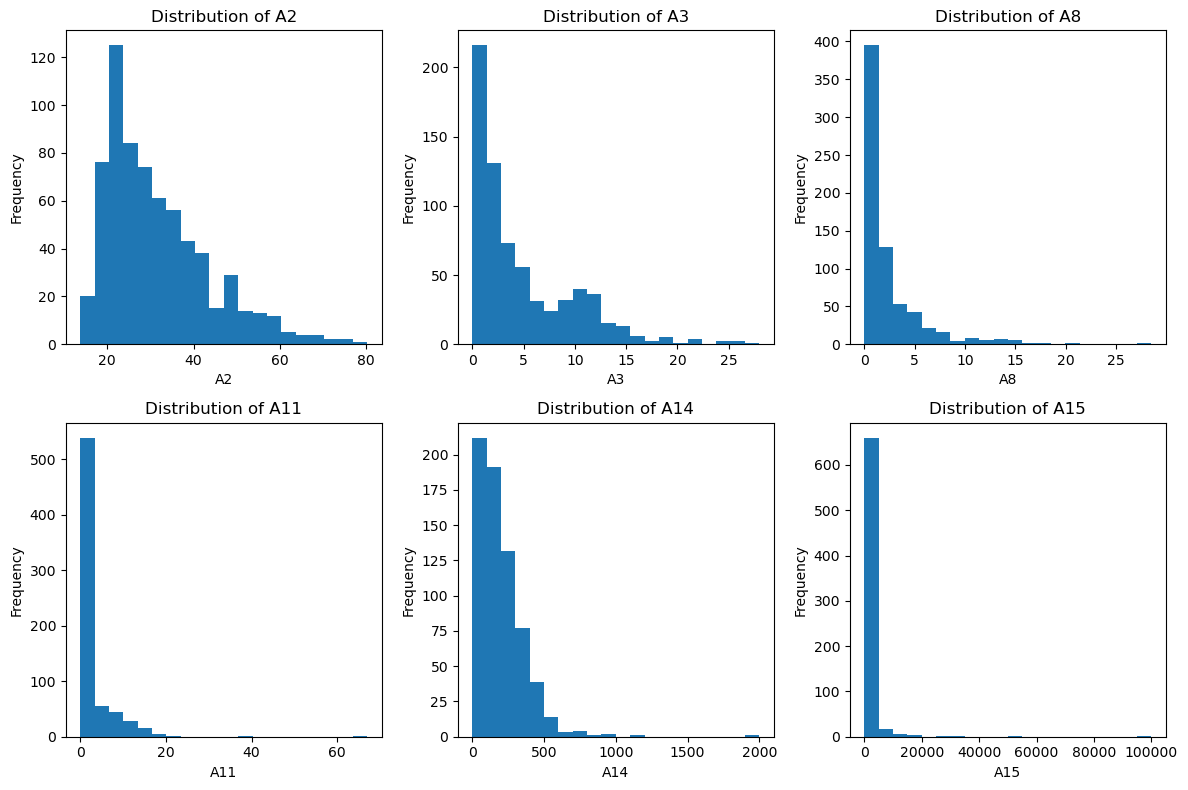

In [23]:
plt.figure(figsize=(12, 8))
continuous_cols = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
df_continuous = df[continuous_cols]
df_continuous
for i, col in enumerate(continuous_cols):
    plt.subplot(2, 3, i + 1)
    plt.hist(df[col], bins=20)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

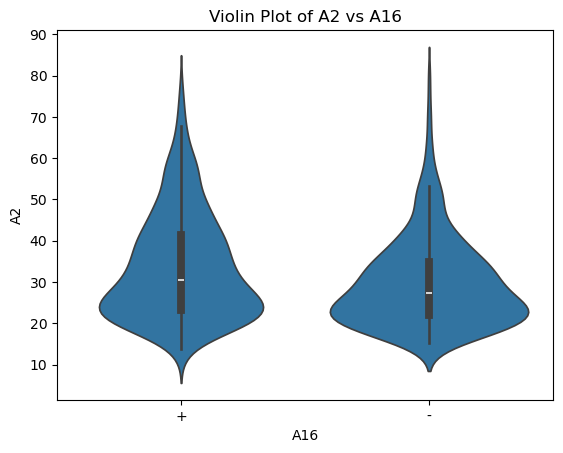

In [24]:
sns.violinplot(x='A16', y='A2', data=df)
plt.xlabel('A16')
plt.ylabel('A2')
plt.title('Violin Plot of A2 vs A16')
plt.show()

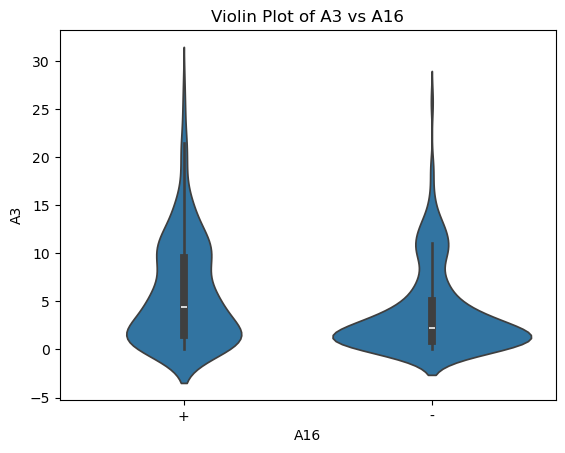

In [25]:
sns.violinplot(x='A16', y='A3', data=df)
plt.xlabel('A16')
plt.ylabel('A3')
plt.title('Violin Plot of A3 vs A16')
plt.show()

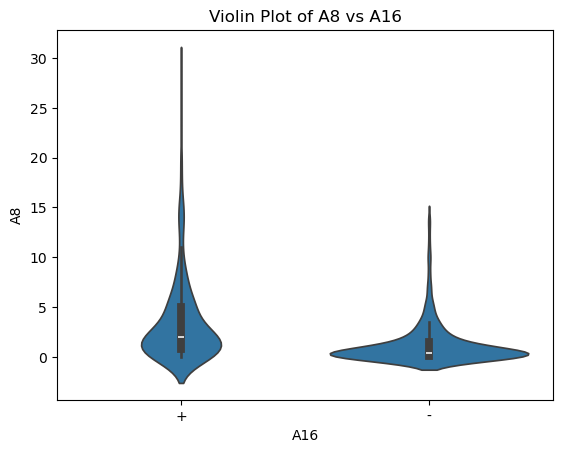

In [26]:
sns.violinplot(x='A16', y='A8', data=df)
plt.xlabel('A16')
plt.ylabel('A8')
plt.title('Violin Plot of A8 vs A16')
plt.show()

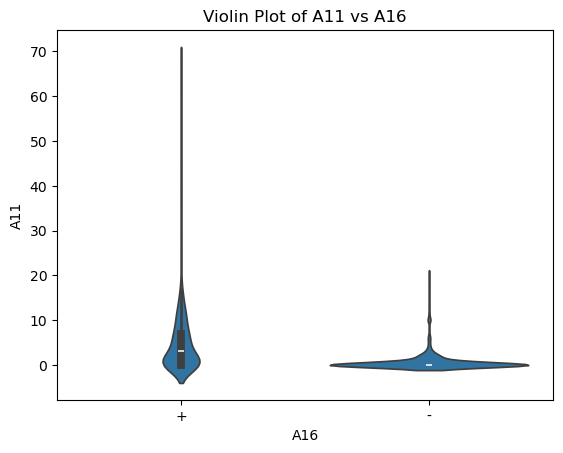

In [27]:
sns.violinplot(x='A16', y='A11', data=df)
plt.xlabel('A16')
plt.ylabel('A11')
plt.title('Violin Plot of A11 vs A16')
plt.show()

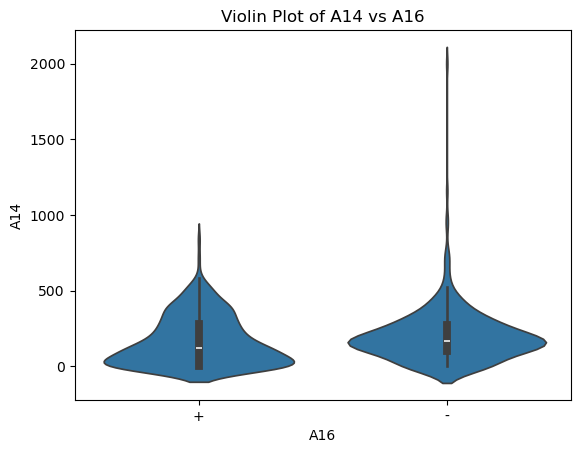

In [28]:
sns.violinplot(x='A16', y='A14', data=df)
plt.xlabel('A16')
plt.ylabel('A14')
plt.title('Violin Plot of A14 vs A16')
plt.show()

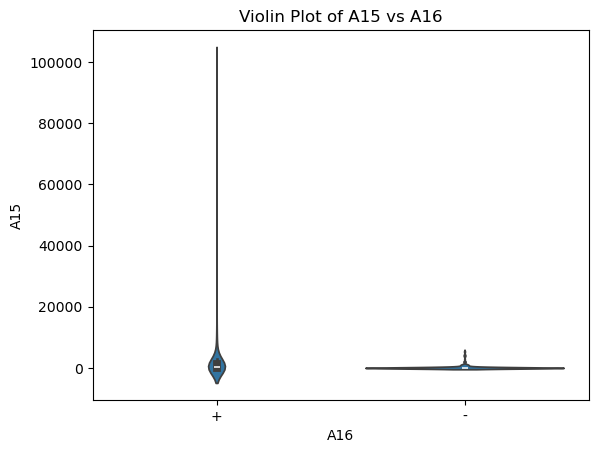

In [29]:
sns.violinplot(x='A16', y='A15', data=df)
plt.xlabel('A16')
plt.ylabel('A15')
plt.title('Violin Plot of A15 vs A16')
plt.show()

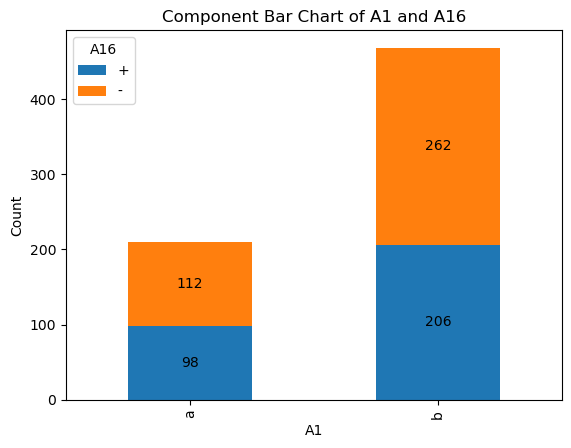

In [30]:
grouped = df.groupby(['A1', 'A16']).size().unstack(fill_value=0)
ax = grouped.plot(kind='bar', stacked=True)
plt.xlabel('A1')
plt.ylabel('Count')
plt.title('Component Bar Chart of A1 and A16')
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x + width / 2, y + height / 2, int(height), ha='center', va='center')
plt.legend(title='A16')
plt.show()

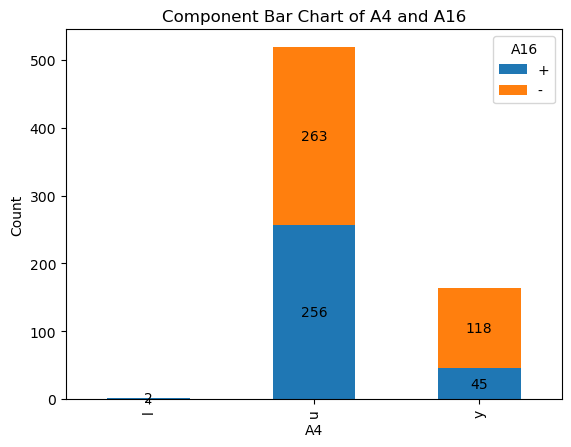

In [31]:
grouped = df.groupby(['A4', 'A16']).size().unstack(fill_value=0)
ax = grouped.plot(kind='bar', stacked=True)
plt.xlabel('A4')
plt.ylabel('Count')
plt.title('Component Bar Chart of A4 and A16')
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x + width / 2, y + height / 2, int(height), ha='center', va='center')
plt.legend(title='A16')
plt.show()

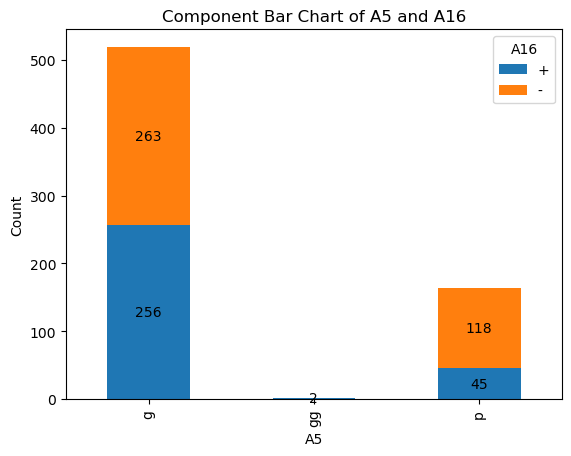

In [32]:
grouped = df.groupby(['A5', 'A16']).size().unstack(fill_value=0)
ax = grouped.plot(kind='bar', stacked=True)
plt.xlabel('A5')
plt.ylabel('Count')
plt.title('Component Bar Chart of A5 and A16')
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x + width / 2, y + height / 2, int(height), ha='center', va='center')
plt.legend(title='A16')
plt.show()

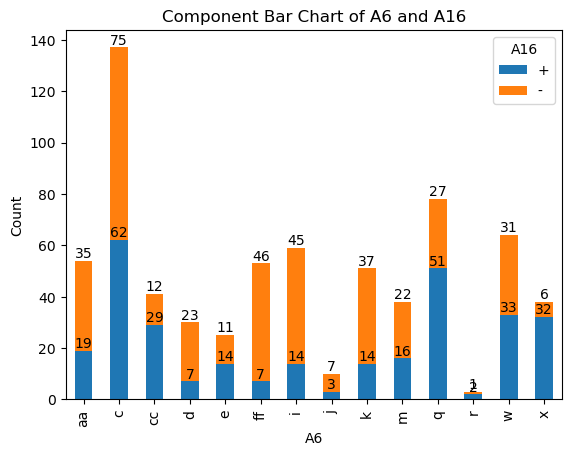

In [33]:
a6_columns = [x for x in df.columns if "A6" in x]
grouped = df.groupby(a6_columns + ['A16']).size().unstack(fill_value=0)
if len(grouped.columns) > 2:
    grouped = grouped[[0, 1]]
ax = grouped.plot(kind='bar', stacked=True)
plt.xlabel('A6')
plt.ylabel('Count')
plt.title('Component Bar Chart of A6 and A16')
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x + width / 2, y + height + 0.1, int(height), ha='center', va='bottom')
plt.legend(title='A16')
plt.show()

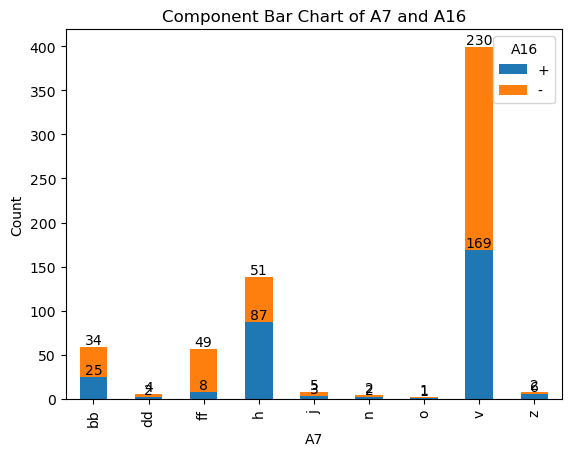

In [34]:
a7_columns = [x for x in df.columns if "A7" in x]
grouped = df.groupby(a7_columns + ['A16']).size().unstack(fill_value=0)
if len(grouped.columns) > 2:
    grouped = grouped[[0, 1]]
ax = grouped.plot(kind='bar', stacked=True)
plt.xlabel('A7')
plt.ylabel('Count')
plt.title('Component Bar Chart of A7 and A16')
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x + width / 2, y + height + 0.1, int(height), ha='center', va='bottom')
plt.legend(title='A16')
plt.show()

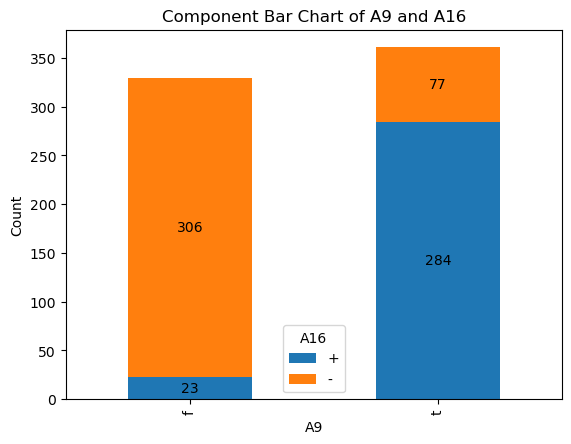

In [35]:
grouped = df.groupby(['A9', 'A16']).size().unstack(fill_value=0)
ax = grouped.plot(kind='bar', stacked=True)
plt.xlabel('A9')
plt.ylabel('Count')
plt.title('Component Bar Chart of A9 and A16')
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x + width / 2, y + height / 2, int(height), ha='center', va='center')
plt.legend(title='A16')
plt.show()

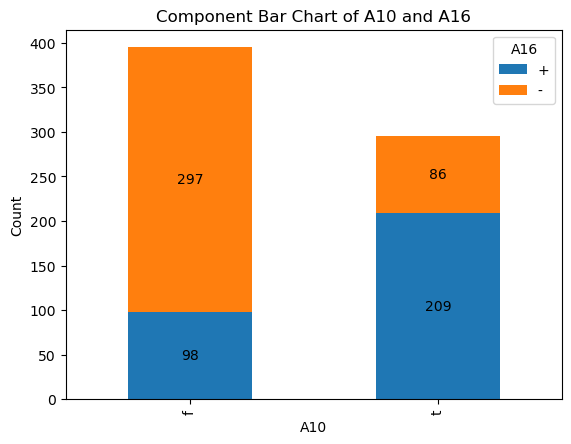

In [36]:
grouped = df.groupby(['A10', 'A16']).size().unstack(fill_value=0)
ax = grouped.plot(kind='bar', stacked=True)
plt.xlabel('A10')
plt.ylabel('Count')
plt.title('Component Bar Chart of A10 and A16')
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x + width / 2, y + height / 2, int(height), ha='center', va='center')
plt.legend(title='A16')
plt.show()

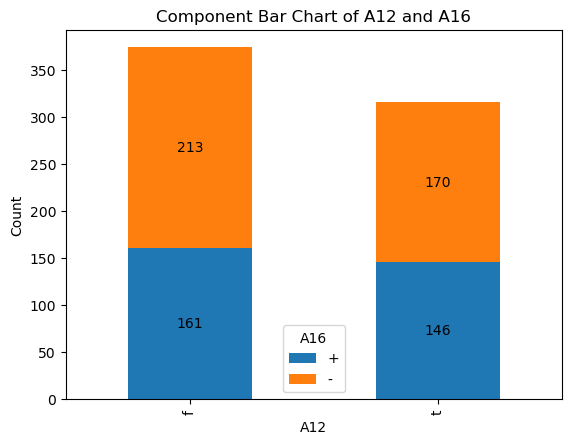

In [37]:
grouped = df.groupby(['A12', 'A16']).size().unstack(fill_value=0)
ax = grouped.plot(kind='bar', stacked=True)
plt.xlabel('A12')
plt.ylabel('Count')
plt.title('Component Bar Chart of A12 and A16')
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x + width / 2, y + height / 2, int(height), ha='center', va='center')
plt.legend(title='A16')
plt.show()

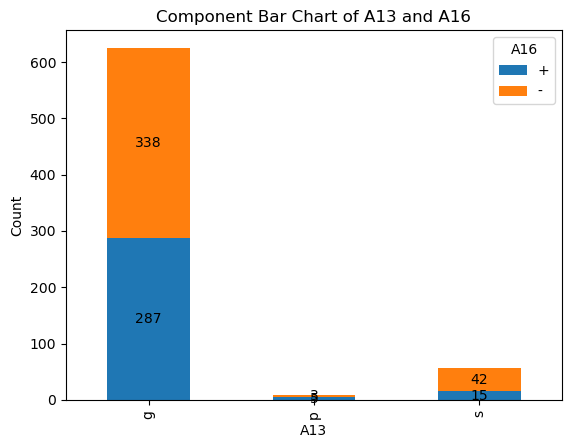

In [38]:
grouped = df.groupby(['A13', 'A16']).size().unstack(fill_value=0)
ax = grouped.plot(kind='bar', stacked=True)
plt.xlabel('A13')
plt.ylabel('Count')
plt.title('Component Bar Chart of A13 and A16')
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x + width / 2, y + height / 2, int(height), ha='center', va='center')
plt.legend(title='A16')
plt.show()

In [39]:
# 2 categorical independent variable with target variable
# List of feature columns
features = ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']

# Target column
target = 'A16'

# Generate all possible pairs of features
feature_pairs = list(combinations(features, 2))

# Convert feature pairs to a numpy array for easier handling
feature_pairs_array = np.array(feature_pairs)

# Significance level
alpha = 0.05

# Initialize lists to store results
significant_pairs = []
non_significant_pairs = []

df_chi2 = pd.DataFrame()

# Loop through all pairs of features
for feature1, feature2 in feature_pairs:
  # Create a combined feature by concatenating Feature1 and Feature2
  df_chi2['CombinedFeature'] = df[f'{feature1}'] + '_' + df[f'{feature2}']
  df_chi2[f'{target}'] = df[f'{target}']

  # Create a contingency table for the pair of features vs. target
  contingency_table = pd.crosstab(df_chi2['CombinedFeature'], df_chi2[f'{target}'])
  print(contingency_table)

  # Perform Chi-Square Test
  chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

  # Print results
  print(f"Feature Pair ({feature1}, {feature2}) vs Target {target}:")
  print(f"Chi-Square Statistic: {chi2_stat}")
  print(f"P-Value: {p_value}")
  if p_value < alpha:
    significant_pairs.append((feature1, feature2))
    print("Since P-Value < 0.05, reject the null hypothesis. This suggests a statistically significant association between the features and the target.")
  else:
    non_significant_pairs.append((feature1, feature2))
    print("Since P-Value ≥ 0.05, fail to reject the null hypothesis. This suggests that there is not enough evidence to conclude that there is an association between the features and the target.")
  print("\n")

# Print significant and non-significant pairs
print("\nSignificant Pairs (p-value < 0.05):")
for pair in significant_pairs:
    print(pair)

print("\nNon-Significant Pairs (p-value >= 0.05):")
for pair in non_significant_pairs:
    print(pair)

A16                +    -
CombinedFeature          
a_l                1    0
a_u               84   83
a_y               11   29
b_l                1    0
b_u              169  175
b_y               34   85
Feature Pair (A1, A4) vs Target A16:
Chi-Square Statistic: 24.63631112568561
P-Value: 0.00016376447350472547
Since P-Value < 0.05, reject the null hypothesis. This suggests a statistically significant association between the features and the target.


A16                +    -
CombinedFeature          
a_g               84   83
a_gg               1    0
a_p               11   29
b_g              169  175
b_gg               1    0
b_p               34   85
Feature Pair (A1, A5) vs Target A16:
Chi-Square Statistic: 24.63631112568561
P-Value: 0.00016376447350472547
Since P-Value < 0.05, reject the null hypothesis. This suggests a statistically significant association between the features and the target.


A16               +   -
CombinedFeature        
a_aa             11  12
a_c     

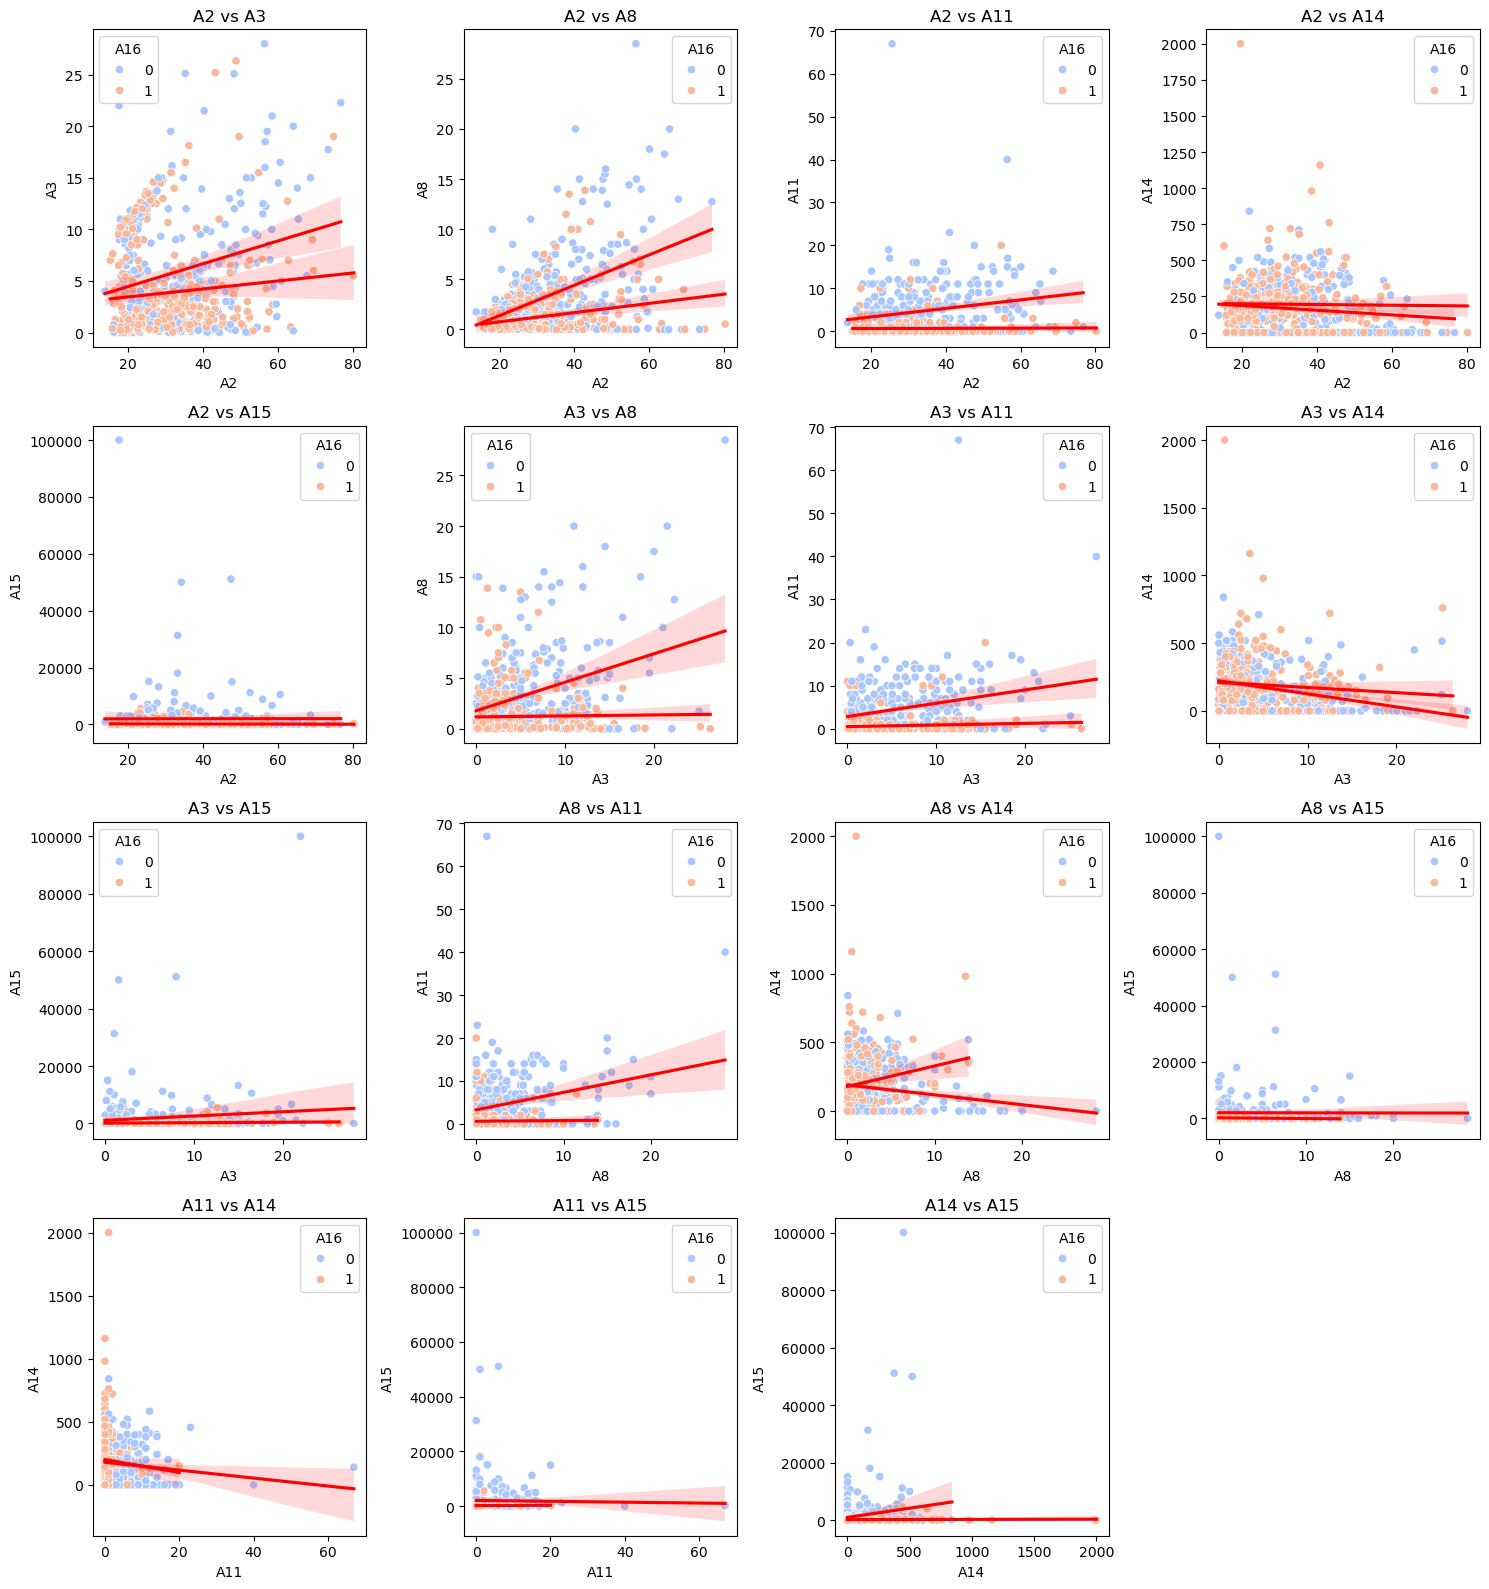

In [40]:
# List of continuous columns
continuous_columns = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']

# Target column
target = 'A16'

# Ensure all continuous columns are numeric
df.loc[:, continuous_columns] = df.loc[:, continuous_columns].apply(pd.to_numeric, errors='coerce')

# Convert target to numeric using Label Encoding if it's categorical
if df[target].dtype == 'object':
    le = LabelEncoder()
    df[target] = le.fit_transform(df.loc[:, target])

# Drop rows with any NaN values in the continuous columns or target column
df_cleaned = df.dropna(subset=continuous_columns + [target])

# Generate all possible pairs of features
feature_pairs = list(combinations(continuous_columns, 2))

# Create subplots layout
n_pairs = len(feature_pairs)
n_cols = 4  # Define number of columns
n_rows = (n_pairs + n_cols - 1) // n_cols  # Calculate number of rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()  # Flatten the axes array to easily index

# Loop through all pairs of features and create scatter plots with regression lines
for idx, (feature1, feature2) in enumerate(feature_pairs):
    # Create scatter plot on the respective axis
    sns.scatterplot(x=feature1, y=feature2, hue=df_cleaned[target], palette='coolwarm', data=df_cleaned, ax=axes[idx])

    # Overlay regression lines for each target category
    for label in df_cleaned[target].unique():
        subset = df_cleaned[df_cleaned[target] == label]
        sns.regplot(x=feature1, y=feature2, data=subset, scatter=False, line_kws={'color':'red'}, ax=axes[idx])

    # Set titles and labels
    axes[idx].set_title(f'{feature1} vs {feature2}')
    axes[idx].set_xlabel(feature1)
    axes[idx].set_ylabel(feature2)

# Remove any unused subplots (in case the number of plots is not a perfect multiple of n_cols)
for i in range(idx + 1, len(axes)):
    fig.delaxes(axes[i])

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [41]:
# 1 categorical + 1 continuous with target
# List of continuous and categorical columns
continuous_cols = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']  # Continuous columns
categorical_cols = ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']  # Example categorical columns

# Target column
target = 'A16'

# Ensure continuous columns are numeric
df[continuous_cols] = df.loc[:, continuous_cols].apply(pd.to_numeric, errors='coerce')

# Encode target if it's categorical
if df[target].dtype == 'object':
    le = LabelEncoder()
    df[target] = le.fit_transform(df.loc[:, target])

# Drop rows with missing values
df_cleaned = df.dropna(subset=continuous_cols + categorical_cols + [target])

# Initialize lists to store results
significant_pairs = []
non_significant_pairs = []

# Significance level
alpha = 0.05

# Loop through each combination of categorical and continuous features
for cat_feature in categorical_cols:
    for cont_feature in continuous_cols:
        print(f"Testing Continuous Feature: {cont_feature} with Categorical Feature: {cat_feature} vs Target: {target}")

        # Prepare the formula for the ANOVA model
        formula = f'{cont_feature} ~ C({cat_feature})'

        # Fit an OLS model and perform ANOVA
        try:
            model = ols(formula, data=df_cleaned).fit()
            anova_table = sm.stats.anova_lm(model, typ=2)  # Type II ANOVA

            # Print results
            print(f"\nANOVA Results for {cont_feature} with {cat_feature}:")
            print(anova_table)

            # Check p-value from the ANOVA table for the categorical feature
            p_value = anova_table["PR(>F)"].iloc[0]  # p-value for the categorical feature (first row)

            if p_value < alpha:
                significant_pairs.append((cont_feature, cat_feature))
                print("Since p-value < 0.05, reject the null hypothesis. This suggests a significant relationship between the categorical feature and the continuous feature.\n")
            else:
                non_significant_pairs.append((cont_feature, cat_feature))
                print("Since p-value ≥ 0.05, fail to reject the null hypothesis. This suggests no significant relationship between the categorical feature and the continuous feature.\n")

        except Exception as e:
            print(f"An error occurred while performing ANOVA: {e}")

# Print significant and non-significant pairs
print("\nSignificant Pairs (p-value < 0.05):")
for pair in significant_pairs:
    print(pair)

print("\nNon-Significant Pairs (p-value ≥ 0.05):")
for pair in non_significant_pairs:
    print(pair)

Testing Continuous Feature: A2 with Categorical Feature: A1 vs Target: A16

ANOVA Results for A2 with A1:
                sum_sq     df         F    PR(>F)
C(A1)       162.544836    1.0  1.160122  0.281839
Residual  91211.713569  651.0       NaN       NaN
Since p-value ≥ 0.05, fail to reject the null hypothesis. This suggests no significant relationship between the categorical feature and the continuous feature.

Testing Continuous Feature: A3 with Categorical Feature: A1 vs Target: A16

ANOVA Results for A3 with A1:
                sum_sq     df         F    PR(>F)
C(A1)        20.075733    1.0  0.794151  0.373177
Residual  16456.947200  651.0       NaN       NaN
Since p-value ≥ 0.05, fail to reject the null hypothesis. This suggests no significant relationship between the categorical feature and the continuous feature.

Testing Continuous Feature: A8 with Categorical Feature: A1 vs Target: A16

ANOVA Results for A8 with A1:
               sum_sq     df         F    PR(>F)
C(A1)      

In [42]:
df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,0
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,0
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,0
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,0
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,b,21.08,10.085,y,p,e,h,1.25,f,f,0,f,g,260.0,0,1
686,a,22.67,0.750,u,g,c,v,2.00,f,t,2,t,g,200.0,394,1
687,a,25.25,13.500,y,p,ff,ff,2.00,f,t,1,t,g,200.0,1,1
688,b,17.92,0.205,u,g,aa,v,0.04,f,f,0,f,g,280.0,750,1


In [43]:
#Check is there any missing value
df.isnull().any().any()

True

In [44]:
#Count the column that having missing value
df.isnull().any().sum()

7

In [45]:
#Display which column have missing value
df.isnull().any()

A1      True
A2      True
A3     False
A4      True
A5      True
A6      True
A7      True
A8     False
A9     False
A10    False
A11    False
A12    False
A13    False
A14     True
A15    False
A16    False
dtype: bool

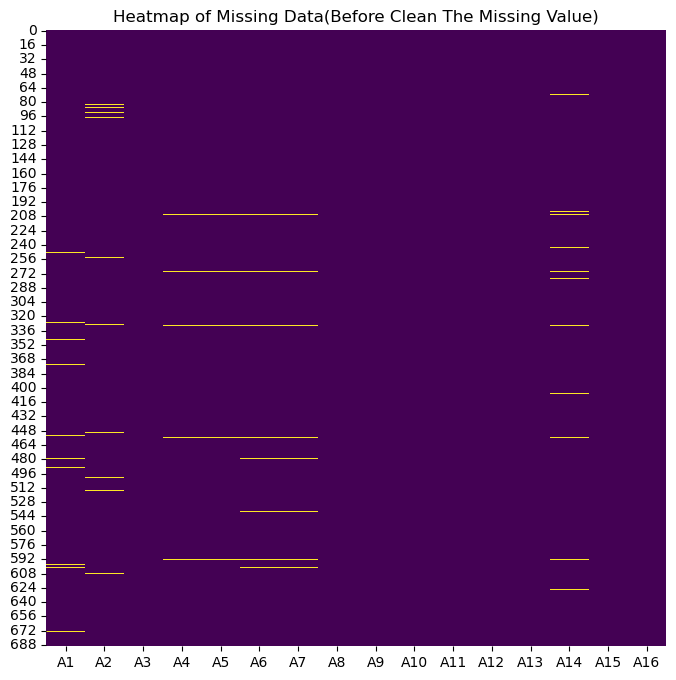

In [46]:
#Heatmap to view the missing values
missing = df.isnull()
count_missing = df.isnull().sum()
percentage_of_missing = count_missing / len(df)*100

plt.figure(figsize=(8,8))
sns.heatmap(df.isnull(),cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Data(Before Clean The Missing Value)')
plt.show()

In [47]:
# Function to perform Chi-Square Test for categorical features
def chi_square_test_missingness(df, feature, target):
    missing = df[feature].isnull().astype(int)
    contingency_table = pd.crosstab(missing, df[target])
    chi2_stat, p_value, _, _ = chi2_contingency(contingency_table)
    return p_value

# Function to perform t-Test for continuous features
def t_test_missingness(df, feature, target):
    missing = df[feature].isnull().astype(int)
    df[target] = pd.factorize(df[target])[0]  # Convert target to numeric codes
    target_missing = df.loc[missing == 1, target]
    target_not_missing = df.loc[missing == 0, target]
    t_stat, p_value = ttest_ind(target_missing, target_not_missing, nan_policy='omit')
    return p_value

# Chi-Square Tests for categorical features
for feature in ['A1', 'A4', 'A5', 'A6', 'A7']:
    p_value = chi_square_test_missingness(df, feature, 'A16')
    print(f"Chi-Square Test for missingness in {feature} related to A16 p-value: {p_value}")

# t-Tests for continuous features
p_value_A2 = t_test_missingness(df, 'A2', 'A16')
print(f"t-Test for missingness in A2 related to A16 p-value: {p_value_A2}")

p_value_A14 = t_test_missingness(df, 'A14', 'A16')
print(f"t-Test for missingness in A14 related to A16 p-value: {p_value_A14}")

Chi-Square Test for missingness in A1 related to A16 p-value: 0.2811518839228987
Chi-Square Test for missingness in A4 related to A16 p-value: 0.493228114119595
Chi-Square Test for missingness in A5 related to A16 p-value: 0.493228114119595
Chi-Square Test for missingness in A6 related to A16 p-value: 1.0
Chi-Square Test for missingness in A7 related to A16 p-value: 1.0
t-Test for missingness in A2 related to A16 p-value: 0.05047579930978366
t-Test for missingness in A14 related to A16 p-value: 0.9033361877053094


In [48]:
# Columns with alphabetic labels
missing_columns = ['A1', 'A2', 'A4', 'A5', 'A6', 'A7', 'A14']

df = df.dropna(subset=missing_columns)

In [49]:
df.isnull().any().any()

False

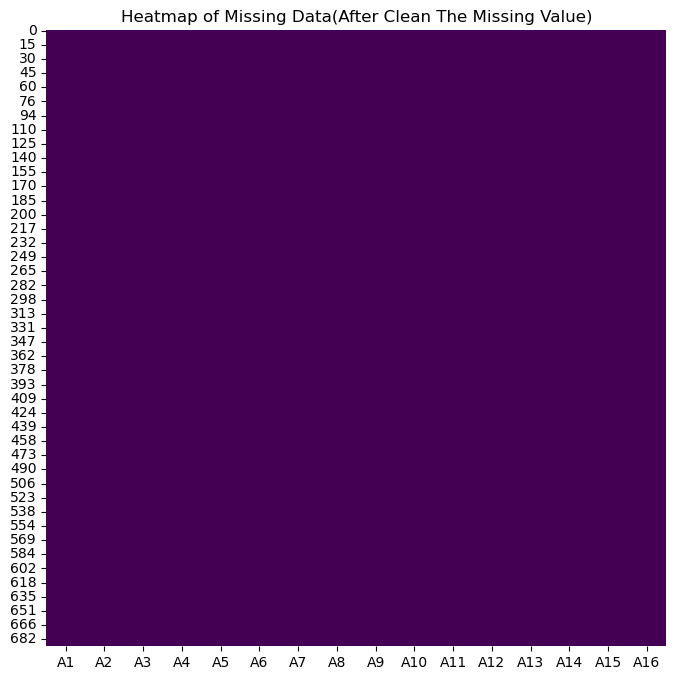

In [50]:
#Heatmap to view the missing values
missing = df.isnull()
count_missing = df.isnull().sum()
percentage_of_missing = count_missing / len(df)*100

plt.figure(figsize=(8,8))
sns.heatmap(df.isnull(),cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Data(After Clean The Missing Value)')
plt.show()

In [51]:
#the number of rows after remove the rows that contain missing values
df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,0
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,0
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,0
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,0
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,b,21.08,10.085,y,p,e,h,1.25,f,f,0,f,g,260.0,0,1
686,a,22.67,0.750,u,g,c,v,2.00,f,t,2,t,g,200.0,394,1
687,a,25.25,13.500,y,p,ff,ff,2.00,f,t,1,t,g,200.0,1,1
688,b,17.92,0.205,u,g,aa,v,0.04,f,f,0,f,g,280.0,750,1


In [52]:
#Check duplicated data
df.duplicated().sum()

0

In [53]:
# List columns with data types int64 and float64
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Display the columns
print(numeric_columns)

Index(['A2', 'A3', 'A8', 'A11', 'A14', 'A15', 'A16'], dtype='object')


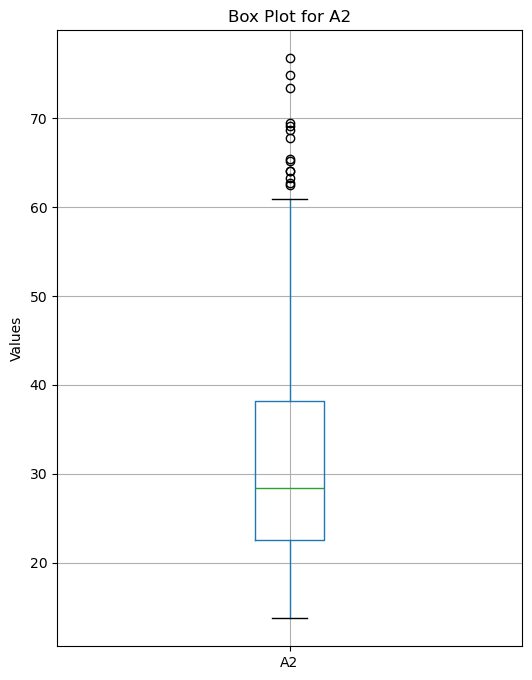

In [54]:
# Create a box plot for A2
plt.figure(figsize=(6,8))
df.boxplot(column=['A2'], showfliers=True)  # 'showfliers=True' will display the outliers

plt.ylabel('Values')
plt.title('Box Plot for A2')

plt.show()

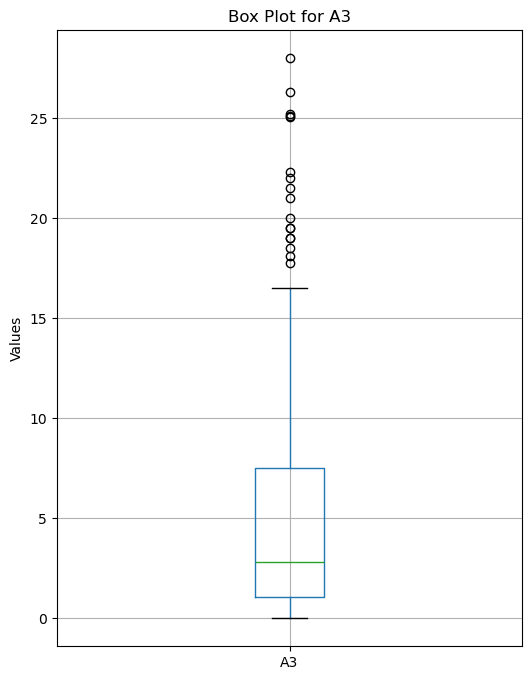

In [55]:
# Create a box plot for A3
plt.figure(figsize=(6,8))
df.boxplot(column=['A3'], showfliers=True)

plt.ylabel('Values')
plt.title('Box Plot for A3')

plt.show()

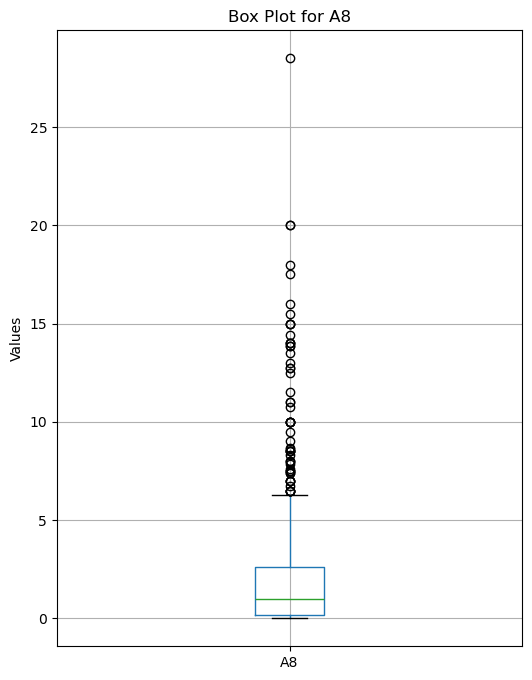

In [56]:
# Create a box plot for A8
plt.figure(figsize=(6,8))
df.boxplot(column=['A8'], showfliers=True)

plt.ylabel('Values')
plt.title('Box Plot for A8')

plt.show()

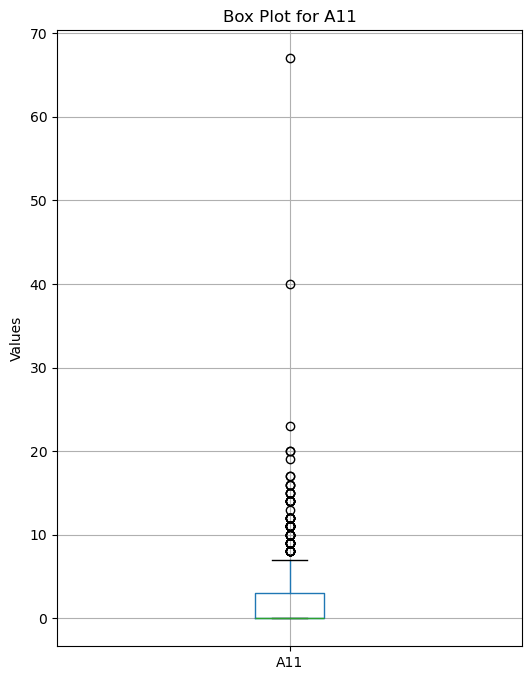

In [57]:
# Create a box plot for A11
plt.figure(figsize=(6,8))
df.boxplot(column=['A11'], showfliers=True)

plt.ylabel('Values')
plt.title('Box Plot for A11')

plt.show()

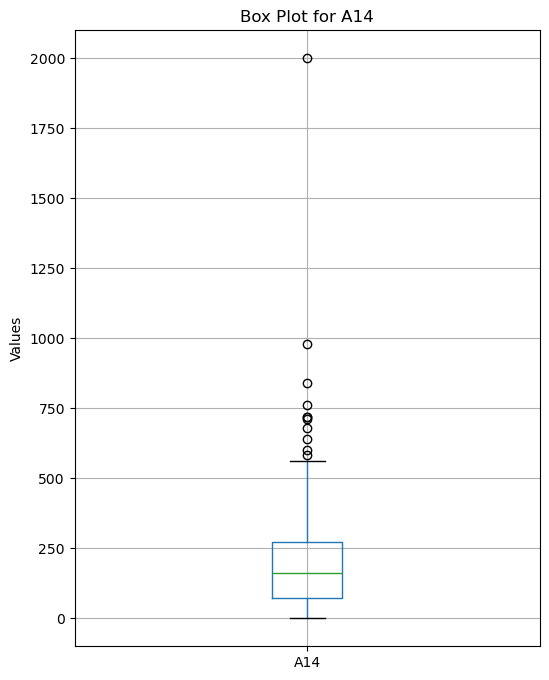

In [58]:
# Create a box plot for A14
plt.figure(figsize=(6,8))
df.boxplot(column=['A14'], showfliers=True)

plt.ylabel('Values')
plt.title('Box Plot for A14')

plt.show()

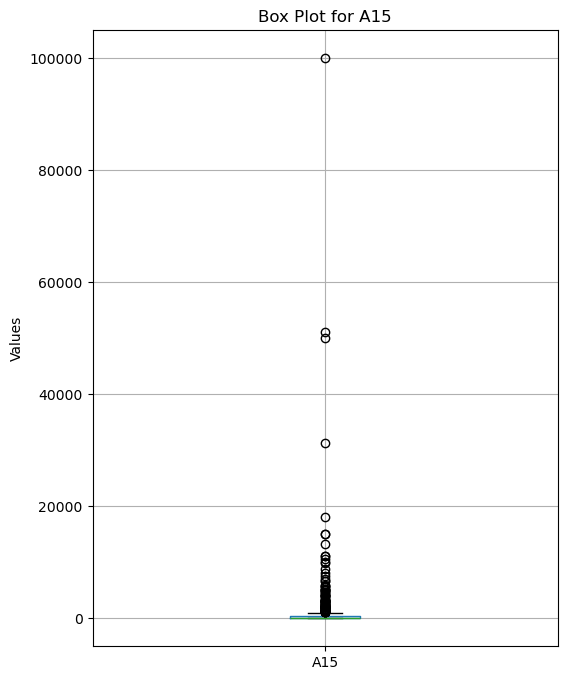

In [59]:
# Create a box plot for A15
plt.figure(figsize=(6,8))
df.boxplot(column=['A15'], showfliers=True)

plt.ylabel('Values')
plt.title('Box Plot for A15')

plt.show()

In [60]:
df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,0
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,0
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,0
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,0
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,b,21.08,10.085,y,p,e,h,1.25,f,f,0,f,g,260.0,0,1
686,a,22.67,0.750,u,g,c,v,2.00,f,t,2,t,g,200.0,394,1
687,a,25.25,13.500,y,p,ff,ff,2.00,f,t,1,t,g,200.0,1,1
688,b,17.92,0.205,u,g,aa,v,0.04,f,f,0,f,g,280.0,750,1


In [61]:
categorical_col = ["A1","A4","A5","A6","A7", "A9","A10","A12","A13","A16"]

# Define the threshold for minority categorization
threshold = 0.05

# Initialize a dictionary to store counts of infrequent values
infrequent_values_count = {}

# Iterate over each categorical column
for col in categorical_col:
    print(f"Processing column: {col}")

    # Calculate the proportion of each category
    colcount = df[col].value_counts()
    total_items = len(df[col])
    col_proportions = colcount / total_items

    # Identify categories with proportion less than the threshold
    infrequent_labels = col_proportions[col_proportions < threshold].index

    # Count the number of infrequent values
    infrequent_count = len(infrequent_labels)
    infrequent_values_count[col] = infrequent_count

    # Optionally, display infrequent values
    print(f"Infrequent categories in '{col}': {list(infrequent_labels)}")
    print(f"Count of infrequent categories in '{col}': {infrequent_count}")

# Display the summary of infrequent values across all columns
print("\nSummary of infrequent values at each categorical columns:")
for col, count in infrequent_values_count.items():
    print(f"Column '{col}': {count} infrequent values")

Processing column: A1
Infrequent categories in 'A1': []
Count of infrequent categories in 'A1': 0
Processing column: A4
Infrequent categories in 'A4': ['l']
Count of infrequent categories in 'A4': 1
Processing column: A5
Infrequent categories in 'A5': ['gg']
Count of infrequent categories in 'A5': 1
Processing column: A6
Infrequent categories in 'A6': ['d', 'e', 'j', 'r']
Count of infrequent categories in 'A6': 4
Processing column: A7
Infrequent categories in 'A7': ['j', 'z', 'dd', 'n', 'o']
Count of infrequent categories in 'A7': 5
Processing column: A9
Infrequent categories in 'A9': []
Count of infrequent categories in 'A9': 0
Processing column: A10
Infrequent categories in 'A10': []
Count of infrequent categories in 'A10': 0
Processing column: A12
Infrequent categories in 'A12': []
Count of infrequent categories in 'A12': 0
Processing column: A13
Infrequent categories in 'A13': ['p']
Count of infrequent categories in 'A13': 1
Processing column: A16
Infrequent categories in 'A16': []

In [62]:
#Imputing
cont_cols = ['A2', 'A3', 'A8', 'A11', 'A14','A15']

def manhattan(p1,p2):
    p1 = list(p1)
    p2 = list(p2)
    return sum([np.abs(p1[i] - p2[i]) for i in range(len(p1))])

def euclidian(p1,p2):
    p1 = list(p1)
    p2 = list(p2)
    return sum([(p1[i] - p2[i])**2 for i in range(len(p1))])**0.5

for col in categorical_col:
  print(col)
  colcount = df[col].value_counts()
  total_items = sum(colcount)
  colcount = colcount/total_items

  imputing_labels = list(colcount[colcount < 0.05].index) #minority is arbitrarily set at 5%
  for minority in imputing_labels:
    affected_rows = df.loc[df[col] == minority].index

    k = 3

    display(df.loc[affected_rows])

    for nin,target in df.loc[affected_rows].iterrows():
      all_distances = {}
      for rownum,comparison in df.iterrows():
        if rownum in affected_rows:
          continue
        all_distances[rownum] = euclidian(target[cont_cols], comparison[cont_cols])
      topk = sorted(list(all_distances.keys()),key = lambda x: all_distances[x])[:k]
      topk_label = [(df.loc[top])[col] for top in topk]
      final_label = sorted(set(topk_label),key=topk_label.count,reverse=True)[0]
      df.loc[nin, col] = final_label

    df.loc[affected_rows]

A1
A4


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
317,b,17.50,22.000,l,gg,ff,o,0.0,f,f,0,t,p,450.0,100000,0
321,a,18.08,0.375,l,gg,cc,ff,10.0,f,f,0,t,s,300.0,0,0


A5


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
317,b,17.50,22.000,u,gg,ff,o,0.0,f,f,0,t,p,450.0,100000,0
321,a,18.08,0.375,u,gg,cc,ff,10.0,f,f,0,t,s,300.0,0,0


A6


...

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
269,b,18.00,0.165,u,g,q,n,0.210,f,f,0,f,g,200.0,40,0
369,b,21.42,0.750,y,p,c,n,0.750,f,f,0,t,g,132.0,2,1
552,b,34.75,15.000,u,g,q,n,5.375,t,t,9,t,g,0.0,134,0
635,b,18.17,2.460,u,g,c,n,0.960,f,t,2,t,g,160.0,587,1


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
262,a,48.17,1.335,u,g,i,o,0.335,f,f,0,f,g,0.0,120,1
317,b,17.50,22.000,u,g,ff,o,0.000,f,f,0,t,p,450.0,100000,0


A9
A10
A12
A13


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
317,b,17.50,22.000,u,g,ff,v,0.0,f,f,0,t,p,450.0,100000,0
424,b,33.67,2.165,u,g,c,v,1.5,f,f,0,f,p,120.0,0,1


A16


In [63]:
# Define the threshold for minority categorization
threshold = 0.05

# Initialize a dictionary to store counts of infrequent values
infrequent_values_count = {}

# Iterate over each categorical column
for col in categorical_col:
    print(f"Processing column: {col}")

    # Calculate the proportion of each category
    colcount = df[col].value_counts()
    total_items = len(df[col])
    col_proportions = colcount / total_items

    # Identify categories with proportion less than the threshold
    infrequent_labels = col_proportions[col_proportions < threshold].index

    # Count the number of infrequent values
    infrequent_count = len(infrequent_labels)
    infrequent_values_count[col] = infrequent_count

    # Optionally, display infrequent values
    print(f"Infrequent categories in '{col}': {list(infrequent_labels)}")
    print(f"Count of infrequent categories in '{col}': {infrequent_count}")

# Display the summary of infrequent values across all columns
print("\nSummary of infrequent values at each categorical columns:")
for col, count in infrequent_values_count.items():
    print(f"Column '{col}': {count} infrequent values")

Processing column: A1
Infrequent categories in 'A1': []
Count of infrequent categories in 'A1': 0
Processing column: A4
Infrequent categories in 'A4': []
Count of infrequent categories in 'A4': 0
Processing column: A5
Infrequent categories in 'A5': []
Count of infrequent categories in 'A5': 0
Processing column: A6
Infrequent categories in 'A6': []
Count of infrequent categories in 'A6': 0
Processing column: A7
Infrequent categories in 'A7': []
Count of infrequent categories in 'A7': 0
Processing column: A9
Infrequent categories in 'A9': []
Count of infrequent categories in 'A9': 0
Processing column: A10
Infrequent categories in 'A10': []
Count of infrequent categories in 'A10': 0
Processing column: A12
Infrequent categories in 'A12': []
Count of infrequent categories in 'A12': 0
Processing column: A13
Infrequent categories in 'A13': []
Count of infrequent categories in 'A13': 0
Processing column: A16
Infrequent categories in 'A16': []
Count of infrequent categories in 'A16': 0

Summary

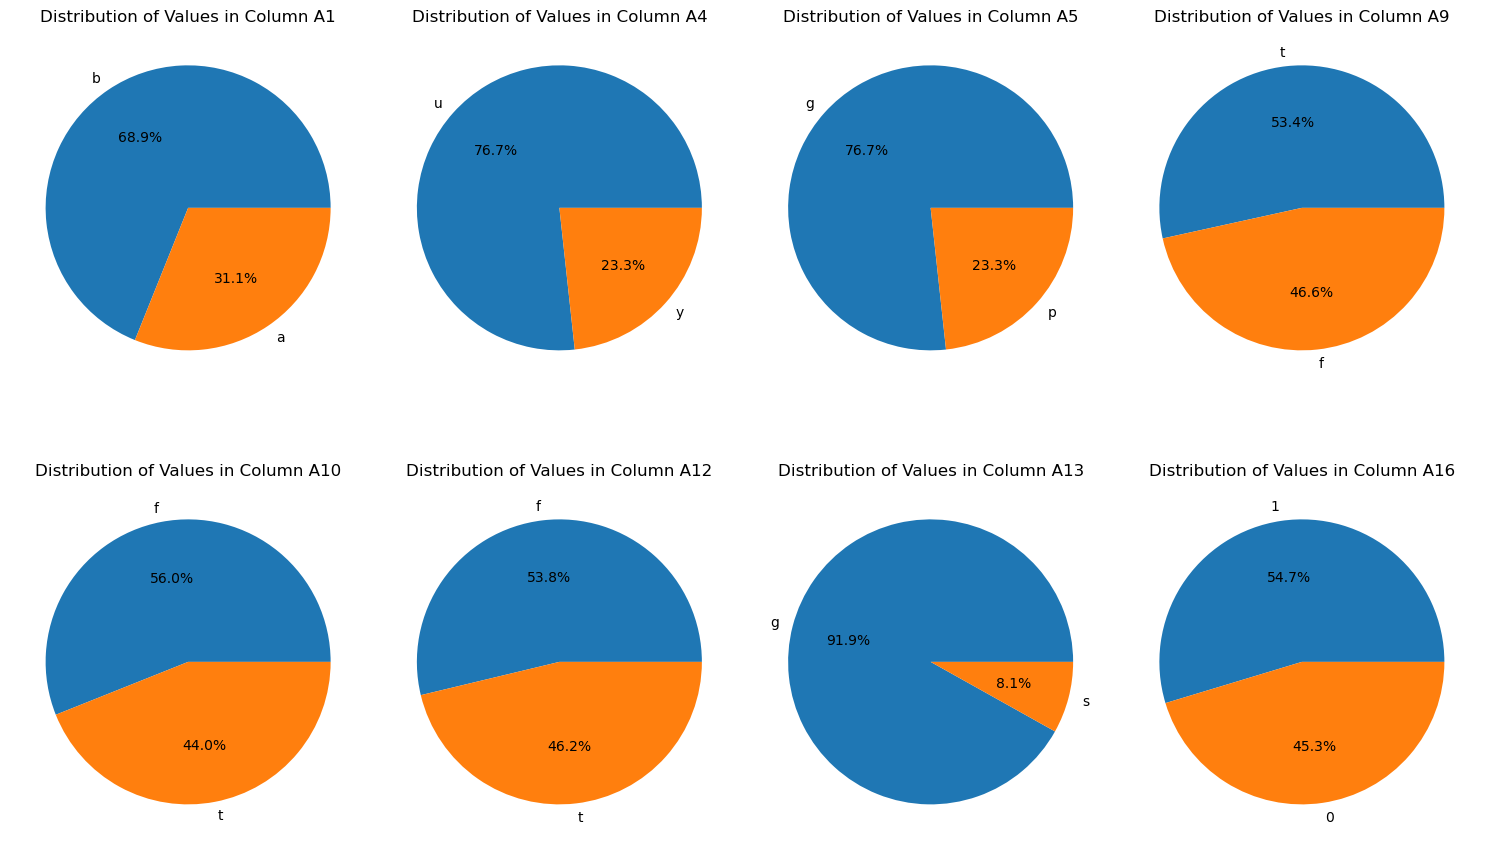

In [64]:
# Create pie chart for categorical columns
plt.figure(figsize=(15, 10))
categorical_cols = ['A1', 'A4', 'A5', 'A9', 'A10', 'A12', 'A13', 'A16']
df_categorical = df[categorical_cols]
df_categorical
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 4, i + 1)
    value_counts = df[col].value_counts()
    plt.pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%')
    plt.title(f'Distribution of Values in Column {col}')

plt.tight_layout()
plt.show()

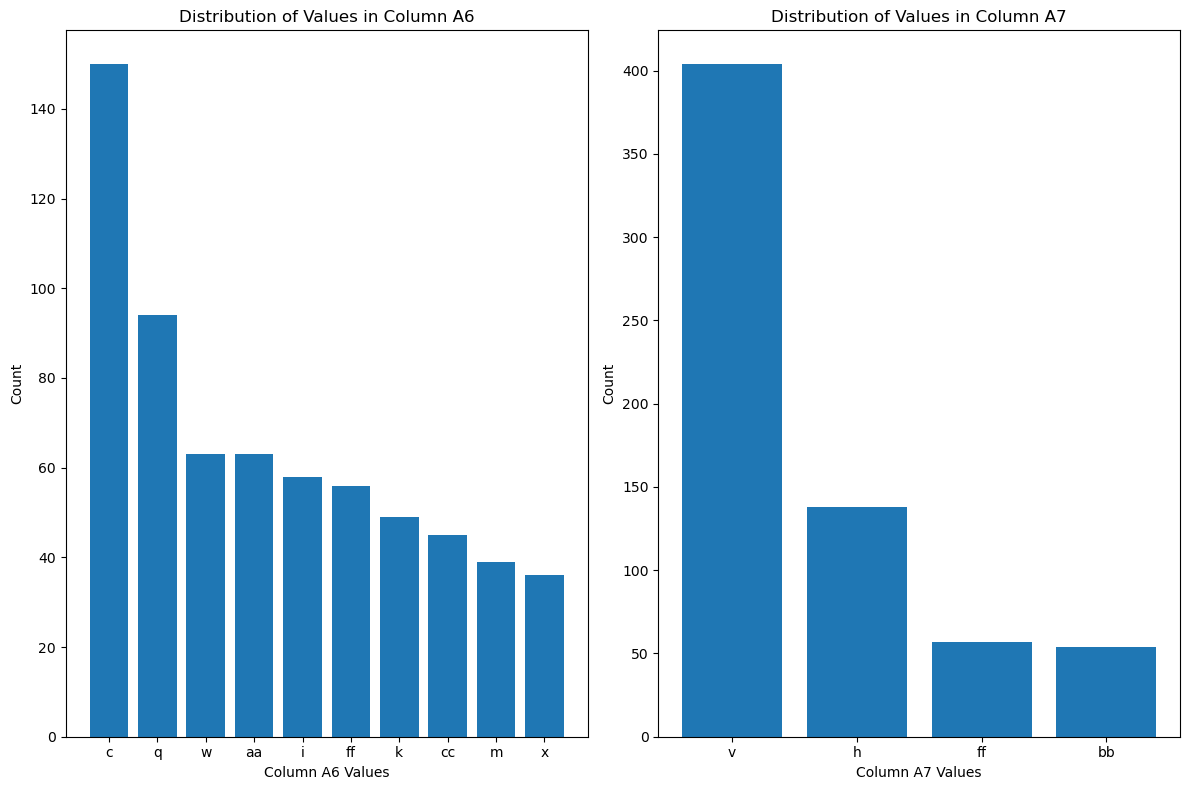

In [65]:
# Create bar chart for categorical columns
plt.figure(figsize=(12, 8))
categorical_cols = ['A6', 'A7']
df_categorical = df[categorical_cols]
df_categorical
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i + 1)
    value_counts = df[col].value_counts()
    plt.bar(value_counts.index, value_counts.values)
    plt.xlabel(f'Column {col} Values')
    plt.ylabel('Count')
    plt.title(f'Distribution of Values in Column {col}')

plt.tight_layout()
plt.show()

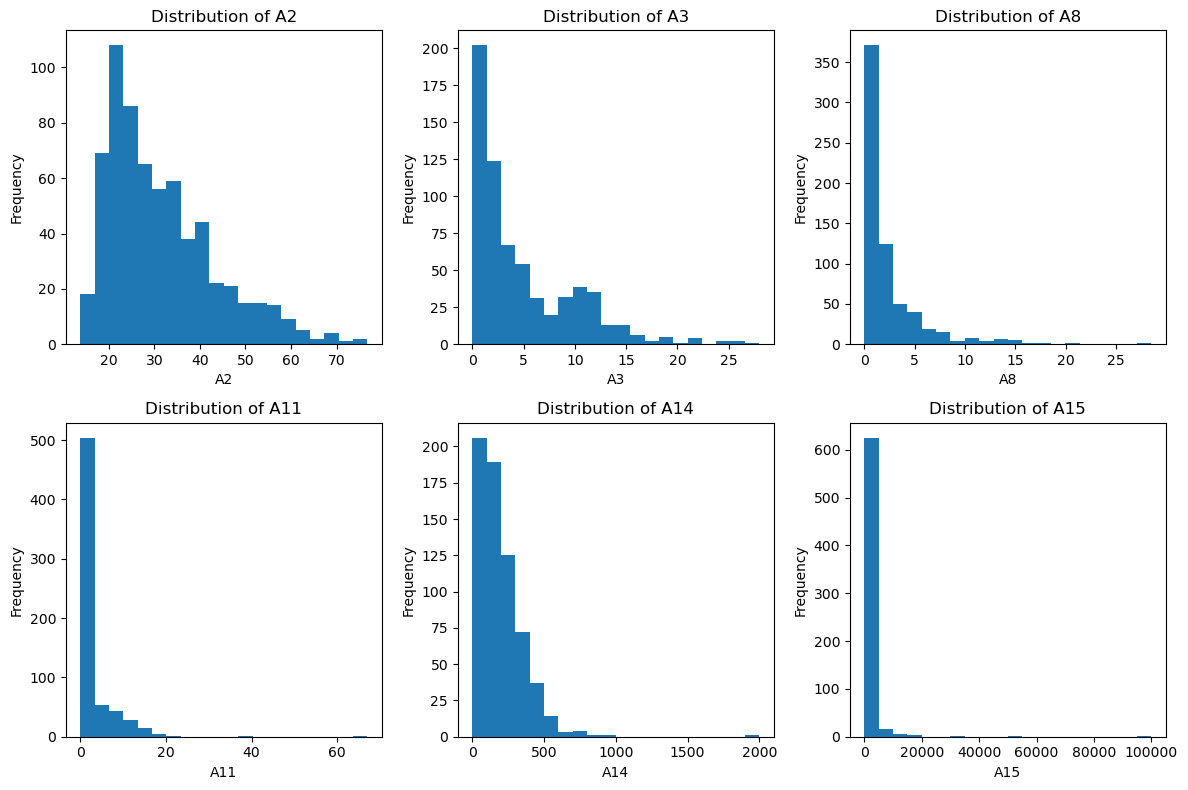

In [66]:
# Create histograms for continuous columns
plt.figure(figsize=(12, 8))
continuous_cols = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
df_continuous = df[continuous_cols]
df_continuous
for i, col in enumerate(continuous_cols):
    plt.subplot(2, 3, i + 1)
    plt.hist(df[col], bins=20)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [67]:
# Box Cox (remove/ minimize skew)
cont_cols = ['A2', 'A3', 'A8', 'A11', 'A14','A15']

# Array to store lambda, mean, and standard deviation 
cont_cols_stats = []

for col in cont_cols:
    new_col, given_lambda = boxcox(df[col] + 0.1)
    df[col] = new_col
    # Calculate mean and standard deviation (square root of variance)
    mean_val = df[col].mean()
    std_dev = np.sqrt(df[col].var())
    
    # Append the lambda, mean, and standard deviation to stats_array
    cont_cols_stats.append((col, given_lambda, mean_val, std_dev))

# Standardization (mean = 0, variance = 1)
scaler = StandardScaler()
df[['A2', 'A3', 'A8', 'A11', 'A14','A15']] = scaler.fit_transform(df[['A2', 'A3', 'A8', 'A11', 'A14','A15']])

C:\Users\yeung\AppData\Local\Temp\ipykernel_16616\13535843.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = new_col
C:\Users\yeung\AppData\Local\Temp\ipykernel_16616\13535843.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['A2', 'A3', 'A8', 'A11', 'A14','A15']] = scaler.fit_transform(df[['A2', 'A3', 'A8', 'A11', 'A14','A15']])


In [68]:
pickle_out = open("classifier.pkl","wb")
pickle.dump(cont_cols_stats, pickle_out)
pickle.dump(df, pickle_out)
pickle_out.close()

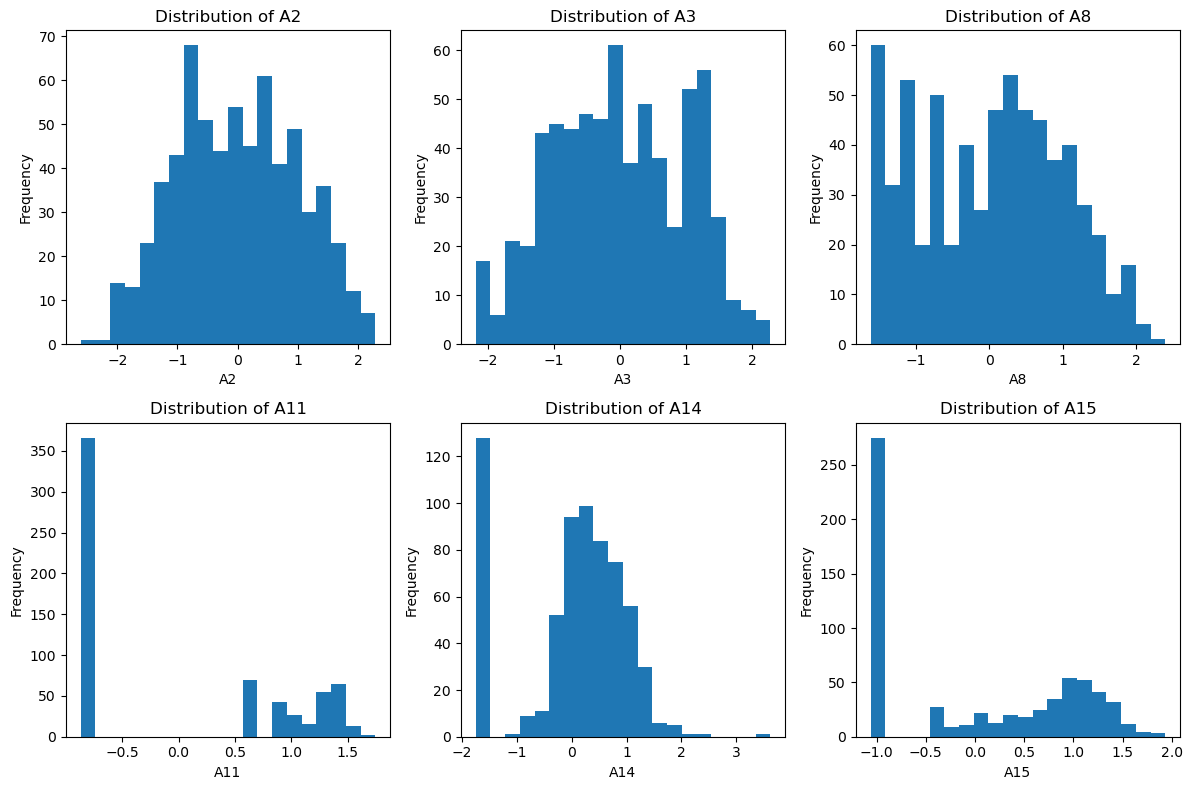

In [69]:
# Create histograms for continuous columns
plt.figure(figsize=(12, 8))
continuous_cols = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
df_continuous = df[continuous_cols]
df_continuous
for i, col in enumerate(continuous_cols):
    plt.subplot(2, 3, i + 1)
    plt.hist(df[col], bins=20)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [70]:
df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,0.207832,-2.180467,u,g,w,v,0.233268,t,t,0.683609,f,g,0.445872,-1.061485,0
1,a,1.770143,0.357565,u,g,q,h,0.831067,t,t,1.282781,f,g,-0.577488,1.054628,0
2,a,-0.483065,-1.189530,u,g,q,h,0.353595,t,f,-0.868749,f,g,0.748840,1.128744,0
3,b,-0.090217,-0.488128,u,g,w,v,0.975422,t,t,1.233339,t,g,-0.093089,-0.103517,0
4,b,-1.132505,0.566284,u,g,w,v,0.440934,t,f,-0.868749,f,s,0.033309,-1.061485,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,b,-0.979608,1.131801,y,p,q,h,0.233268,f,f,-0.868749,f,g,0.676786,-1.061485,1
686,a,-0.734828,-0.959843,u,g,c,v,0.546180,f,t,0.945865,t,g,0.437209,0.985847,1
687,a,-0.387859,1.436940,y,p,ff,ff,0.546180,f,t,0.683609,t,g,0.437209,-0.374607,1
688,b,-1.559166,-1.599114,u,g,aa,v,-1.372017,f,f,-0.868749,f,g,0.748840,1.110825,1


In [71]:
#Data transformation 2 (object, label encoding)
# List of columns to apply Label Encoding
label_columns = ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13', 'A16']

# Initialize Label Encoder
label_encoder = LabelEncoder()

# Apply Label Encoding to each column
for col in label_columns:
    df.loc[:, col] = label_encoder.fit_transform(df[col])

# Display the DataFrame to confirm the changes
print(df.head())

  A1        A2        A3 A4 A5 A6 A7        A8 A9 A10       A11 A12 A13  \
0  1  0.207832 -2.180467  0  0  8  3  0.233268  1   1  0.683609   0   0   
1  0  1.770143  0.357565  0  0  7  2  0.831067  1   1  1.282781   0   0   
2  0 -0.483065 -1.189530  0  0  7  2  0.353595  1   0 -0.868749   0   0   
3  1 -0.090217 -0.488128  0  0  8  3  0.975422  1   1  1.233339   1   0   
4  1 -1.132505  0.566284  0  0  8  3  0.440934  1   0 -0.868749   0   1   

        A14       A15  A16  
0  0.445872 -1.061485    0  
1 -0.577488  1.054628    0  
2  0.748840  1.128744    0  
3 -0.093089 -0.103517    0  
4  0.033309 -1.061485    0  


In [72]:
print(df.columns)

Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11',
       'A12', 'A13', 'A14', 'A15', 'A16'],
      dtype='object')


In [73]:
print(df.dtypes)

A1      object
A2     float64
A3     float64
A4      object
A5      object
A6      object
A7      object
A8     float64
A9      object
A10     object
A11    float64
A12     object
A13     object
A14    float64
A15    float64
A16      int64
dtype: object


In [74]:
# List of columns to apply One-Hot Encoding
one_hot_columns = ['A6', 'A7']

# Apply One-Hot Encoding
df_one_hot = pd.get_dummies(df, columns=one_hot_columns)

# Display the combined DataFrame to confirm the changes
print(df_one_hot.head())

  A1        A2        A3 A4 A5        A8 A9 A10       A11 A12  ...   A6_4  \
0  1  0.207832 -2.180467  0  0  0.233268  1   1  0.683609   0  ...  False   
1  0  1.770143  0.357565  0  0  0.831067  1   1  1.282781   0  ...  False   
2  0 -0.483065 -1.189530  0  0  0.353595  1   0 -0.868749   0  ...  False   
3  1 -0.090217 -0.488128  0  0  0.975422  1   1  1.233339   1  ...  False   
4  1 -1.132505  0.566284  0  0  0.440934  1   0 -0.868749   0  ...  False   

    A6_5   A6_6   A6_7   A6_8   A6_9   A7_0   A7_1   A7_2   A7_3  
0  False  False  False   True  False  False  False  False   True  
1  False  False   True  False  False  False  False   True  False  
2  False  False   True  False  False  False  False   True  False  
3  False  False  False   True  False  False  False  False   True  
4  False  False  False   True  False  False  False  False   True  

[5 rows x 28 columns]


In [75]:
print(df_one_hot.columns)
df = df_one_hot

Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13',
       'A14', 'A15', 'A16', 'A6_0', 'A6_1', 'A6_2', 'A6_3', 'A6_4', 'A6_5',
       'A6_6', 'A6_7', 'A6_8', 'A6_9', 'A7_0', 'A7_1', 'A7_2', 'A7_3'],
      dtype='object')


In [76]:
df

,A1,A2,A3,A4,A5,A8,A9,A10,A11,A12,...,A6_4,A6_5,A6_6,A6_7,A6_8,A6_9,A7_0,A7_1,A7_2,A7_3
0,1,0.207832,-2.180467,0,0,0.233268,1,1,0.683609,0,...,False,False,False,False,True,False,False,False,False,True
1,0,1.770143,0.357565,0,0,0.831067,1,1,1.282781,0,...,False,False,False,True,False,False,False,False,True,False
2,0,-0.483065,-1.189530,0,0,0.353595,1,0,-0.868749,0,...,False,False,False,True,False,False,False,False,True,False
3,1,-0.090217,-0.488128,0,0,0.975422,1,1,1.233339,1,...,False,False,False,False,True,False,False,False,False,True
4,1,-1.132505,0.566284,0,0,0.440934,1,0,-0.868749,0,...,False,False,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,1,-0.979608,1.131801,1,1,0.233268,0,0,-0.868749,0,...,False,False,False,True,False,False,False,False,True,False
686,0,-0.734828,-0.959843,0,0,0.546180,0,1,0.945865,1,...,False,False,False,False,False,False,False,False,False,True
687,0,-0.387859,1.436940,1,1,0.546180,0,1,0.683609,1,...,False,False,False,False,False,False,False,True,False,False
688,1,-1.559166,-1.599114,0,0,-1.372017,0,0,-0.868749,0,...,False,False,False,False,False,False,False,False,False,True


In [77]:
df.dtypes

A1       object
A2      float64
A3      float64
A4       object
A5       object
A8      float64
A9       object
A10      object
A11     float64
A12      object
A13      object
A14     float64
A15     float64
A16       int64
A6_0       bool
A6_1       bool
A6_2       bool
A6_3       bool
A6_4       bool
A6_5       bool
A6_6       bool
A6_7       bool
A6_8       bool
A6_9       bool
A7_0       bool
A7_1       bool
A7_2       bool
A7_3       bool
dtype: object

In [78]:
seed = 8888

independent = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10','A11','A12','A13','A14','A15']
dependent = "A16"

# KNN
x_data = df.loc[:, df.columns != dependent]
y_data = df[dependent]

x_train , x_test, y_train, y_test = train_test_split(x_data,y_data,test_size = 0.2, random_state=seed)

best_model = None
best_prediction = None
best_acc = 0

for k in range(2,21):
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(x_train,y_train)

  y_pred = knn.predict(x_test)

  acc = accuracy_score(y_test, y_pred)
  if acc > best_acc:
    best_model = knn
    best_prediction = y_pred
    best_acc = acc

print(confusion_matrix(y_test, best_prediction))
print(accuracy_score(y_test, best_prediction) * 100, "%")
print(classification_report(y_test, best_prediction))

knn_acc = best_acc

[[52 12]
 [ 3 64]]
88.54961832061069 %
              precision    recall  f1-score   support

           0       0.95      0.81      0.87        64
           1       0.84      0.96      0.90        67

    accuracy                           0.89       131
   macro avg       0.89      0.88      0.88       131
weighted avg       0.89      0.89      0.88       131



In [79]:
# ANN with Limited memory BFGS (using OneHot)
x_data = df.loc[:, df.columns != dependent]
y_data = df[dependent]

x_train , x_test, y_train, y_test = train_test_split(x_data,y_data,test_size = 0.2,random_state = seed)

ann = MLPClassifier(hidden_layer_sizes=(30,20,12,7), solver="lbfgs",max_iter=1000,random_state=40)

ann.fit(x_train,y_train)

y_pred = ann.predict(x_test)

print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred) * 100, "%")
print(classification_report(y_test, y_pred))

ann_acc = accuracy_score(y_test, y_pred)

[[56  8]
 [ 5 62]]
90.07633587786259 %
              precision    recall  f1-score   support

           0       0.92      0.88      0.90        64
           1       0.89      0.93      0.91        67

    accuracy                           0.90       131
   macro avg       0.90      0.90      0.90       131
weighted avg       0.90      0.90      0.90       131



In [80]:
# Logistic Regression
x_data = df.loc[:, df.columns != dependent]
y_data = df[dependent]

x_train , x_test, y_train, y_test = train_test_split(x_data,y_data,test_size = 0.2, random_state = seed)

logreg = LogisticRegression(solver="liblinear", max_iter=1000,random_state=40)
logreg.fit(x_train,y_train)

y_pred = logreg.predict(x_test)

print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred) * 100, "%")
print(classification_report(y_test, y_pred))

logreg_acc = accuracy_score(y_test, y_pred)

[[58  6]
 [ 4 63]]
92.36641221374046 %
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        64
           1       0.91      0.94      0.93        67

    accuracy                           0.92       131
   macro avg       0.92      0.92      0.92       131
weighted avg       0.92      0.92      0.92       131



In [81]:
# SVM
x_data = df.loc[:, df.columns != dependent]
y_data = df[dependent]

x_train , x_test, y_train, y_test = train_test_split(x_data,y_data,test_size = 0.2, random_state = seed)

svm = SVC(random_state=40)
svm.fit(x_train,y_train)
y_pred = svm.predict(x_test)

print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred) * 100, "%")
print(classification_report(y_test, y_pred))

svm_acc = accuracy_score(y_test, y_pred)

[[57  7]
 [ 3 64]]
92.36641221374046 %
              precision    recall  f1-score   support

           0       0.95      0.89      0.92        64
           1       0.90      0.96      0.93        67

    accuracy                           0.92       131
   macro avg       0.93      0.92      0.92       131
weighted avg       0.93      0.92      0.92       131



In [82]:
# Ensemble
x_data = df.loc[:, df.columns != dependent]
y_data = df[dependent]

x_train , x_test, y_train, y_test = train_test_split(x_data,y_data,test_size = 0.2, random_state = seed)

models = [ann,knn,svm]
model_names = ["ANN","KNN","SVM"]
model_prediction = pd.DataFrame()
for m, mn in zip(models, model_names):
  model_prediction.insert(0,mn,m.predict(x_test))

y_pred = model_prediction.mode(axis="columns")

print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred) * 100, "%")
print(classification_report(y_test, y_pred))

ensem_acc = accuracy_score(y_test, y_pred)

[[57  7]
 [ 2 65]]
93.12977099236642 %
              precision    recall  f1-score   support

           0       0.97      0.89      0.93        64
           1       0.90      0.97      0.94        67

    accuracy                           0.93       131
   macro avg       0.93      0.93      0.93       131
weighted avg       0.93      0.93      0.93       131



In [83]:
print("KNN Accuracy : {:.2f}%".format(knn_acc * 100))
print("ANN Accuracy : {:.2f}%".format(ann_acc * 100))
print("Logistic Reg Accuracy : {:.2f}%".format(logreg_acc * 100))
print("SVM Accuracy : {:.2f}%".format(svm_acc * 100))
print("Ensemble Accuracy : {:.2f}%".format(ensem_acc * 100))

KNN Accuracy : 88.55%
ANN Accuracy : 90.08%
Logistic Reg Accuracy : 92.37%
SVM Accuracy : 92.37%
Ensemble Accuracy : 93.13%


In [84]:
pickle_out = open("classifier.pkl","ab")
pickle.dump(models, pickle_out)
pickle_out.close()